# Deep Q-Network implementation.

<!-- This homework shamelessly demands you to implement DQN — an approximate Q-learning algorithm with experience replay and target networks — and see if it works any better this way. -->

Это домашнее задани требует от вас реализовать DQN — приблизительный алгоритм Q-обучения с воспроизведением опыта и целевыми сетями — и посмотреть, работает ли он лучше таким образом.

**Papers:**
- [1] Original paper, 2013: https://arxiv.org/pdf/1312.5602.pdf
- [2] Extended paper, Nature, 2015: https://web.stanford.edu/class/psych209/Readings/MnihEtAlHassibis15NatureControlDeepRL.pdf
- [3] Rainbow, 2017: https://arxiv.org/pdf/1710.02298.pdf

In [1]:
# import sys, os
# if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
#     os.makedirs('dqn', exist_ok=True)
#     os.makedirs('test_td_loss', exist_ok=True)

#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash

#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/atari_wrappers.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/utils.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/replay_buffer.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/framebuffer.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/analysis.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/dqn/logger.py -P dqn/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/test_td_loss/compute_td_loss.py -P test_td_loss/
#     !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week04_approx_rl/requirements.txt

#     !pip install -r requirements.txt

#     !touch .setup_complete

# # Этот код создает виртуальный дисплей для рисования игровых изображений.
# # Он не будет работать, если на вашем компьютере установлен монитор.
# if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
#     !bash ../xvfb start
#     os.environ['DISPLAY'] = ':1'

In [2]:
%matplotlib inline
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt

gym.register_envs(ale_py)

# 1. Предобработка

## 1.1. Let's play some old videogames
<!-- ![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/nerd.png) -->

**These are various versions of Breakout provided by Gynmasium:**

In [3]:
all_names = list(gym.envs.registry.keys())
names_breakout = [name for name in all_names if "Break" in name]
names_breakout

['Breakout-v0',
 'Breakout-v4',
 'BreakoutNoFrameskip-v0',
 'BreakoutNoFrameskip-v4',
 'ALE/Breakout-v5']

In [4]:
# ENV_NAME = "BreakoutDeterministic-v4"  # this one is simpler
ENV_NAME = "ALE/Breakout-v5"

Если вам интересно узнать о среде `Atari` в `Gymnasium`, пожалуйста, обратитесь к:
- [4] Gymnasium docs: https://gymnasium.farama.org/environments/atari/
- [5] Longer paper: https://arxiv.org/abs/1709.06009
- [6] Shorter paper: https://www.ijcai.org/Proceedings/2018/0787.pdf

На данный момент достаточно знать о средах `v5`:
- рекомендуется использовать среды `v5`
- `frame_skip=5`, агенту показывается каждый 5-й кадр, и выбранное действие выполняется в течение следующих 5 ходов
- случайность определяется `repeat_action_probability=0,25`: с этой вероятностью предыдущее действие будет выполнено вместо выбранного действия

## 1.2. Getting to know the Environment

**Let's see what observations look like.**

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


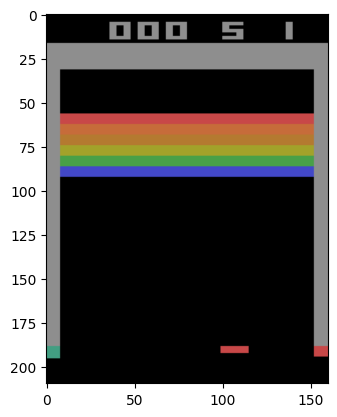

In [5]:
env = gym.make(ENV_NAME, render_mode="rgb_array")
env.reset()
plt.imshow(env.render())
plt.show()

**Some more observations, coming from taking random actions**

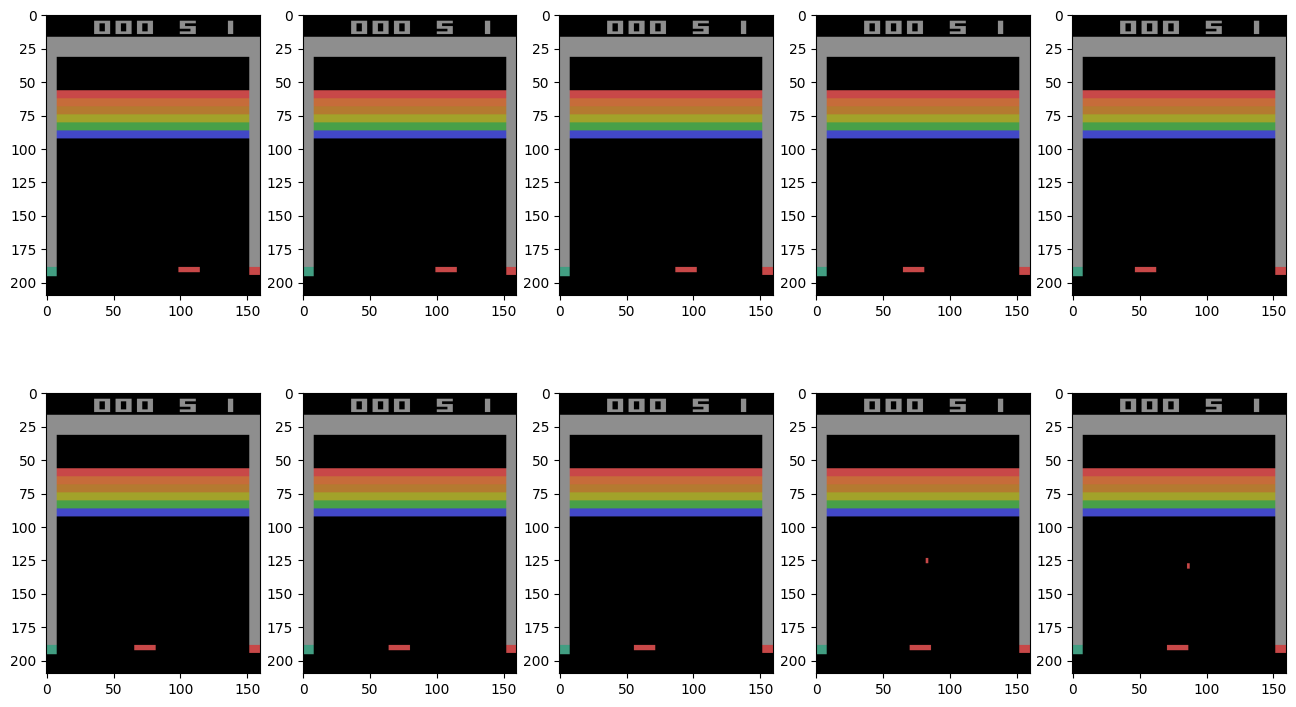

In [6]:
env = gym.make(ENV_NAME, render_mode="rgb_array")
env.reset()

n_cols = 5
n_rows = 2
fig = plt.figure(figsize=(16, 9))

for row in range(n_rows):
    for col in range(n_cols):
        ax = fig.add_subplot(n_rows, n_cols, row * n_cols + col + 1)
        ax.imshow(env.render())
        env.step(env.action_space.sample())
plt.show()

<!-- **About the game:** You have 5 lives and get points for breaking the wall. Higher bricks cost more than the lower ones. There are 4 actions: start game (should be called at the beginning and after each life is lost), move left, move right and do nothing. There are some common wrappers used for Atari environments. -->

**Об игре:**

У вас есть 5 жизней, и вы получаете очки за разрушение стены. Более высокие кирпичи стоят дороже, чем нижние.

Есть 4 действия:
- начать игру (следует вызывать в начале и после потери каждой жизни)
- двигаться влево
- двигаться вправо
- ничего не делать.

Существует несколько распространенных оболочек, используемых в средах `Atari`.


**Let's take a look at action meanings:**

In [7]:
env.unwrapped.get_action_meanings()

['NOOP', 'FIRE', 'RIGHT', 'LEFT']

<!-- 1. NOOP stands for the action of doing nothing
2. Right and Left move the platform to the corresponding direction
3. Fire releases the ball in the beginning of a life

In this assignment we will wrap the environment to execute the "Fire" action in the beginning of a life automatically. It will turn the "FIRE" action into another "NOOP".  
Also, we will wrap the environment to make an episode last for 1 life instead of 5 ones.  
These transforms are claimed as non-recommended in the paper [5] but it was done in the original paper [1] and it will help the training to converge faster.  -->

1. `NOOP` – ничего не делать
2. 'RIGHT' и 'LEFT' – перемещени платформы
3. 'FIRE' выпускает мяч в начале жизни

В этом задании мы создадим окружение, чтобы автоматически выполнить действие `FIRE` в начале жизни. 
Это превратит действие `FIRE` в еще один `NOOP`.  

Кроме того, мы изменим окружение, чтобы эпизод длился 1 жизнь вместо 5.  

Эти преобразования заявлены как не рекомендованные в статье [5], но они были выполнены в оригинальной статье [1], и это поможет быстрее согласовать обучение.

**Let's play a little.**

<!-- Pay attention to zoom and fps args of play function. Control: A, D, space. -->

Обратите внимание на параметры масштабирования и частоты кадров в секунду в режиме воспроизведения.

Управление: `A`, `D`, `пробел`.

In [8]:
# # Does not work in Colab.
# Even on a local laptop breaks matplotlib rendering. So it's recommended to restart the notebook after playing.
# # Use the Escape button to continue.

# from gymnasium.utils.play import play

# play(env=gym.make(ENV_NAME, render_mode="rgb_array"), zoom=4, fps=10)

## 1.3. Wrapping the Environment

In [9]:
def make_basic_env():
    return gym.make(ENV_NAME, render_mode="rgb_array")

### Processing game image

Let's check the shape and the dtype of the observation:

In [10]:
env = make_basic_env()
obs, *_ = env.reset()
obs.shape, obs.dtype

((210, 160, 3), dtype('uint8'))

<!-- Raw Atari images are large, 210x160x3 by default. However, we don't need that level of detail in order to learn from them.

We can thus save a lot of time by preprocessing game image, including
* Resizing to a smaller shape, 64x64 (or 84 x 84, which is used in literature)
* Converting to grayscale
* Cropping irrelevant image parts (top, bottom and edges) \[we won't do this\]

The images are of the uint8 dtype.  
uint8 stands for the 8-bit unsigned integer type.  
We are going to store 10^5 or 10^6 observations in memory (RAM), so let's pay attention to preserving the 8-bit type after our transforms. -->

Изображения в формате `Raw Atari` по умолчанию имеют размер `210x160x3`. Однако нам не нужен такой уровень детализации, чтобы извлекать из них уроки.

Таким образом, мы можем сэкономить много времени, предварительно обработав игровое изображение, включая
* Изменение размера до `64x64` (или `84x84`, как указано в литературе)
* Преобразование в оттенки серого
* Обрезка ненужных частей изображения (верхней, нижней и по краям) \[мы не будем этого делать\]

Изображения относятся к типу `uint8 dtype`.  
- `uint8` обозначает 8-разрядный целочисленный тип без знака.  
- Мы собираемся сохранить `10^5` или `10^6` наблюдений в памяти (RAM), поэтому давайте обратим внимание на сохранение 8-битного типа после наших преобразований.

(84, 84) uint8


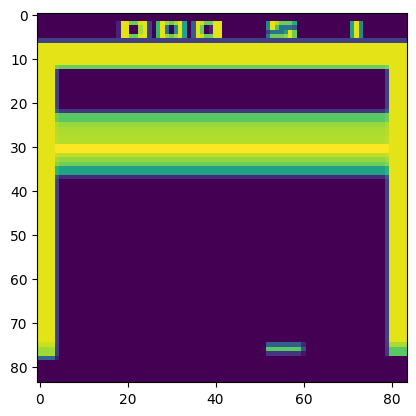

In [11]:
def apply_gray_scale_wrap(env):
    # With the argument values chosen as below, the gym.wrappers.AtariPreprocessing wrapper
    # преобразуем изображения в grayscale и уменьшим их размер до screen_size
    env = gym.wrappers.AtariPreprocessing(
        env,
        noop_max=0,  # the default value 30 can be harmful with FireResetEnv and frame_skip=5
        frame_skip=1,  # frame_skip has already been set to 5 inside the env
        terminal_on_life_loss=False,  # we do this explicitly in the FireResetEnv wrapper
        screen_size=84  # please use 84 (which is the standard value) or 64 (which will save some computations and memory)
    )
    return env


env = make_basic_env()
env = apply_gray_scale_wrap(env)

obs, *_ = env.reset()

assert obs.dtype == np.dtype('uint8'), obs_dtype

print(obs.shape, obs.dtype)
plt.imshow(obs)
plt.show()

## 1.4. Atari specific wrappers
<!-- ### Специальные обертки для `Atari` -->

<!-- We try to make our lives a little easier with the following wrappers:
1. EpisodicLifeEnv it makes the signal that dropping a ball is not good more explicit
2. Using FireResetEnv: with it the agent doesn't have to perform a special action to fire the ball in the beginning of a life -->

Мы стараемся немного облегчить нашу жизнь с помощью следующих оберток (wrappers):
1. `EpisodicLifeEnv` делает сигнал о том, что бросать мяч нехорошо, более явным
2. Использование `FireResetEnv`: с его помощью агенту не нужно выполнять специальное действие, чтобы запустить мяч в начале жизни

(84, 84) uint8


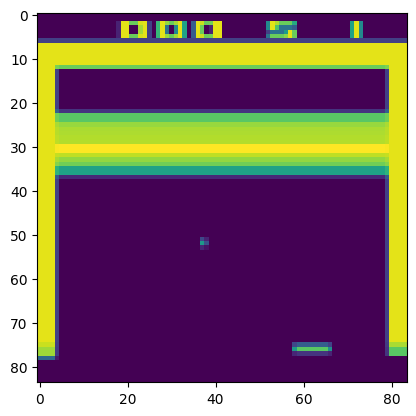

In [12]:
from dqn.atari_wrappers import FireResetEnv
from dqn.atari_wrappers import EpisodicLifeEnv

def apply_atary_specific_wrap(env):
    env = EpisodicLifeEnv(env)
    env = FireResetEnv(env)
    return env

env = make_basic_env()
env = apply_gray_scale_wrap(env)
env = apply_atary_specific_wrap(env)

obs, *_ = env.reset()

print(obs.shape, obs.dtype)
plt.imshow(obs)
plt.show()

## 1.5.FrameStack

<!-- To make the game playable from a single observation (note the direction of the ball), we stack 4 consecutive frames: -->

Складываем 4 последовательных кадра:

Shape: (4, 84, 84), dtype: uint8, Python object type: <class 'numpy.ndarray'>

Frames, left to right: from older to more recent. The ball is dropping.


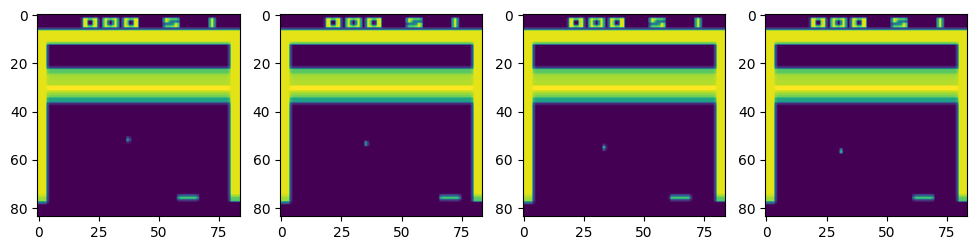

In [13]:
from gym.wrappers import FrameStack

N_FRAMES_STACKED = 4

def make_final_env(apply_frame_stack=True):
    """
    Builds the environment with all the wrappers applied.
    The environment is meant be used directly as an RL algorithm input.

    apply_frame_stack=False can be useful for vecotrized environments, which are not required for this assignment.
    """
    env = make_basic_env()
    env = apply_gray_scale_wrap(env)
    env = apply_atary_specific_wrap(env)
    if apply_frame_stack:
        env = gym.wrappers.FrameStackObservation(env, 4) # your code. Please, use gym.wrappers.FrameStackObservation
    return env


env = make_final_env()

obs, *_ = env.reset()
print(f"Shape: {obs.shape}, dtype: {obs.dtype}, Python object type: {type(obs)}")
for _ in range(N_FRAMES_STACKED - 1):
    obs, *_ = env.step(env.action_space.sample())
print()


print("Frames, left to right: from older to more recent. The ball is dropping.")
_, axes = plt.subplots(figsize=(len(obs) * 3, 4), ncols=len(obs))
for ax, frame in zip(axes, obs):
    ax.imshow(frame)
plt.show()

**That is the final version of the environment we are going to do RL on.**

<!-- **Let's discuss the representation of an obsevation.**\ -->
<!-- An observation is a 4-frame-stack of grayscale images with reduced resolution.\
Memory (RAM) is a high-demand resource in this task. That's why:
1. We use the uint8 dtype instead of float32 the neural network will operate on
2. We don't represent them as numpy.ndarrays. **LazyFrames** are used by gym.wrappers.FrameStack instead. 2 consecutive observations share 3 of 4 frames. LazyFrames make use of this fact to save memory.
When we feed the observations to neural networks, we should remember to scale them to the \[-1, 1\] range. We'll implement scaling as the first layer of a neural network, but that'll be later. -->


**Давайте обсудим представление наблюдения.**

Наблюдение представляет собой набор из 4 кадров изображений в оттенках серого с уменьшенным разрешением.\
Оперативная память (RAM) является наиболее востребованным ресурсом в этой задаче. Вот почему:

1. Мы используем `uint8 dtype` вместо `float32`, с которым будет работать нейронная сеть
2. Мы не представляем их как `numpy.ndarrays`. `LazyFrames` используются `gym.wrappers.FrameStack` вместо этого используется стекирование кадров. 2 последовательных наблюдения разделяют 3 из 4 кадров. `LazyFrames` используют этот факт для экономии памяти.
Когда мы передаем данные наблюдений в нейронные сети, мы должны помнить о необходимости их масштабирования в диапазоне \[-1, 1\]. Мы реализуем масштабирование на первом уровне нейронной сети, но об этом позже.

**The ball is dropping, but its hard to notice. Let's define a function to render more human-readable images:**

/kernel/lib/python3.10/site-packages/ml_kernel/kernel.py:232: DeprecationWarning: Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  language = self._parent_header['metadata'].get('language')


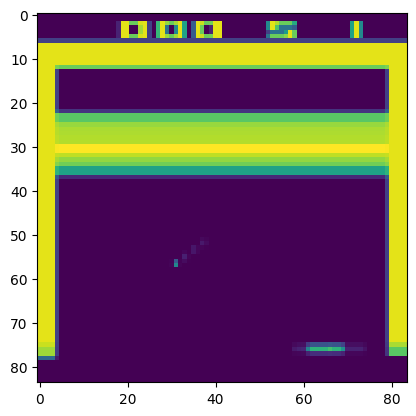

In [14]:
def merge_frame_stack_to_plot(frame_stack_obs):
    """
    Вспомогательная функция для отображения стека кадров в виде единого изображения, понятного пользователю.

    Более яркие пиксели отображаются более свежими, более бледные - более старыми.
    Движение меняется от бледного к яркому.

    Обратите внимание!
    Эта функция предназначена для удобства и не должна использоваться как часть
    предварительной обработки данных для агента обучения с подкреплением.
    """
    weights = np.ones(frame_stack_obs.shape[0], dtype=float)
    weights[-1] += weights.sum()
    weights /= weights.sum()
    result = (weights[:, None, None] * frame_stack_obs).sum(0)
    return result


obs_joint = merge_frame_stack_to_plot(obs)
plt.imshow(obs_joint)
plt.show()

In [15]:
obs_joint.shape

(84, 84)

Hope that's better

In [16]:
N_ACTIONS = env.action_space.n
STATE_SHAPE = env.observation_space.shape

<!-- **Let's see if the game is still playable after applying the wrappers.** -->

<!-- At playing the EpisodicLifeEnv wrapper seems not to work but actually it does (because after when life finishes a new ball is dropped automatically - it means that FireResetEnv wrapper understands that a new episode began).

**Not supported for now.** -->


**Давайте посмотрим, можно ли по-прежнему играть в игру после применения wrappers.**

При воспроизведении кажется, что оболочка `EpisodicLifeEnv` не работает, но на самом деле это так (потому что после завершения life автоматически выпадает новый шарик - это означает, что оболочка `FireResetEnv` понимает, что начался новый эпизод).

**Пока не поддерживается.**

# 2. DQN as it is (10 pts)

## 2.1. Building a network

**Dueling Network Architectures for Deep Reinforcement Learning:** https://arxiv.org/pdf/1511.06581.pdf

Nature DQN ([2]), expects height=width=84

<!-- <img src="img/dueling_nature.png" alt="dueling_nature" width="500"/> -->
![img](https://github.com/yandexdataschool/Practical_RL/raw/master/week04_approx_rl/img/dueling_nature.png)

In [17]:
import torch
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [18]:
N_ACTIONS, N_FRAMES_STACKED

/kernel/lib/python3.10/site-packages/ml_kernel/kernel.py:232: DeprecationWarning: Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  language = self._parent_header['metadata'].get('language')


(4, 4)

## 2.2. Backbone and DuelingDqnHead

In [19]:
class ConvBackbone(nn.Sequential):
    """
    The convolutional part of a DQN model.
    Please, don't think about input scaling here: it will be implemented below.
    """
    def __init__(self, c_in: int = N_FRAMES_STACKED) -> None:
        super().__init__(
            nn.Conv2d(in_channels=4, out_channels=32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
        )


class DuelingDqnHead(nn.Module):
    def __init__(self, n_actions, inp_size=64 * 7 * 7, hidden_size=512) -> None:
        super().__init__()

        # advantage branch
        self.adv_stream = nn.Sequential(
            nn.Linear(in_features=inp_size,out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size,out_features=n_actions)
        )

        # value branch (скаляр)
        self.value_stream = nn.Sequential(
            nn.Linear(in_features=inp_size,out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size,out_features=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.ndim == 2, x.shape  # (batch_size, n_features)
        # your code
        # When calculating the mean advantage, please, remember, x is a batched input!

        A = self.adv_stream(x)        # (B, n_actions)
        V = self.value_stream(x)      # (B, 1)

        # среднее преимущество по действиям для каждой записи в батче
        A_mean = A.mean(dim=1, keepdim=True)   # (B, 1)

        Q = V + (A - A_mean)  # broadcasting: (B,1) + (B, n_actions) -> (B, n_actions)
        return Q

Давайте проведем простой тест для архитектуры:

In [20]:
@torch.no_grad()
def test_network_part_shapes(backbone, head):
    batch_size = 3
    env = make_final_env()
    s, _ = env.reset()
    inp = torch.rand(batch_size, *s.shape)

    features = backbone(inp)
    qvalues = head(features)

    assert features.ndim == 2, features.shape
    assert features.shape[0] == batch_size, features.shape

    assert qvalues.ndim == 2, qvalues.shape
    assert qvalues.shape[0] == batch_size, qvalues.shape
    assert qvalues.shape[1] == N_ACTIONS, qvalues.shape

    print("Test passed!")

test_network_part_shapes(
    backbone=ConvBackbone(N_FRAMES_STACKED),
    head=DuelingDqnHead(N_ACTIONS),
)

Test passed!


## 2.3. Scaling

In [21]:
MAX_UINT_8 = 2 ** 8 - 1

# нормализуют в диапазон [0,1]
class InputScaler(nn.Module):
    def __init__(self, mult=1 / MAX_UINT_8):
        super().__init__()
        self.mult = mult

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * self.mult


# Масштабирование градиентов.
# Градиенты потоков Value и Advantage должны быть отмасштабированы
# чтобы их вклад был сбалансирован.
class GradScalerFunctional(torch.autograd.Function):
    """
    Функция torch.autograde.работает как идентификатор при прямом проходе
    и масштабирует градиент с помощью scale_factor при обратном проходе.
    """
    @staticmethod
    def forward(ctx, input, scale_factor):
        ctx.scale_factor = scale_factor
        return input

    @staticmethod
    def backward(ctx, grad_output):
        scale_factor = ctx.scale_factor
        grad_input = grad_output * scale_factor
        return grad_input, None


class GradScaler(nn.Module):
    """
    An nn.Module incapsulating GradScalerFunctional
    """
    def __init__(self, scale_factor: float):
        super().__init__()
        self.scale_factor = scale_factor

    def forward(self, x):
        return GradScalerFunctional.apply(x, self.scale_factor)


class DQNetworkDueling(nn.Sequential):
    def __init__(self, c_in: int, n_actions: int) -> None:
        input_scaler = InputScaler()  # the inputs come from the uint8 range
        backbone = ConvBackbone(c_in=c_in)  # your code
        grad_scaler = GradScaler(1 / 2**0.5)  # Dueling DQN suggests do scale the gradient by 1 / sqrt(2)
        head = DuelingDqnHead(n_actions=n_actions)
        super().__init__(input_scaler, backbone, grad_scaler, head)

In [22]:
@torch.no_grad()
def test_network_shapes(model):
    batch_size = 3
    env = make_final_env()
    s, _ = env.reset()
    inp = torch.rand(batch_size, *s.shape)

    qvalues = model(inp)

    assert qvalues.ndim == 2, qvalues.shape
    assert qvalues.shape[0] == batch_size, qvalues.shape
    assert qvalues.shape[1] == N_ACTIONS, qvalues.shape

    print("Test passed!")

test_network_shapes(model=DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS))

Test passed!


**Теперь давайте перенесем нашу модель в класс Agent.**  
Он будет реализовывать epsilon-жадную политику для numpy ndarrays.

## 2.4. DQNAgent

In [23]:
from threading import Condition

class DQNAgent(nn.Module):
    """
    Epsilon-greedy policy c модулем оценки torch.nn.Module Q-value.
    """

    def __init__(self, q_network: nn.Module, epsilon=1) -> None:
        super().__init__()
        self.epsilon = epsilon
        self.q_network = q_network

    def forward(self, state_t):
        """
        Принимает данные наблюдения агента (тензор), возвращает qvalues (тензор)
            :параметр state_t: batch из 4-кадровых буферов, shape = [batch_size, 4, h, w]
        """
        # Используйте свою сеть для вычисления значений q для заданного состояния
        # print("state_t.shape = ", state_t.shape)
        qvalues = self.q_network(state_t)
        return qvalues

    @torch.no_grad()  # вы не нуждаетесь в autograd здесь, так что давайте сохраним вычисления
    def get_qvalues(self, states: np.ndarray) -> np.ndarray:
        """
        like forward, but works on numpy arrays, not tensors
        """
        model_device = next(self.parameters()).device
        states_pt = torch.tensor(np.array(states), device=model_device, dtype=torch.float32)
        # Use your network to compute qvalues for given state
        # print("DQNAgent states_pt=", states_pt.shape)
        qvalues_pt = self.forward(states_pt)
        qvalues = qvalues_pt.data.cpu().numpy()
        return qvalues

    def sample_actions_by_qvalues(self, qvalues: np.ndarray, greedy: bool = False) -> np.ndarray:
        """
        Выбирайте действия с заданными q-значениями.
        Используйте эпсилон-жадную стратегию исследования.
        """
        batch_size, n_actions = qvalues.shape
        # greedy_actions = # your code

        # 1) Жадные действия
        greedy_actions = qvalues.argmax(axis=-1)  # your code
        if greedy:
            return greedy_actions

        # 2) Случайные действия
        random_actions = np.random.randint(low=0, high=n_actions, size=batch_size)

        # 3) Для каждого элемента батча подбрасываем Bernoulli
        should_explore = np.random.binomial(n=1, p=self.epsilon, size=batch_size).astype(bool)

        # 4) Выбираем поэлементно: explore → random, exploit → greedy
        epsilon_greedy_actions = np.where(
            should_explore, # condition
            random_actions, # true
            greedy_actions  # false
        )

        return epsilon_greedy_actions

    def sample_actions(self, states: np.ndarray, greedy: bool = False) -> np.ndarray:
        # print("sample_actions states = ", states.shape)
        qvalues = self.get_qvalues(states)
        actions = self.sample_actions_by_qvalues(qvalues, greedy)
        return actions

In [24]:
test_network_shapes(
    model=DQNAgent(DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS))
)

Test passed!


In [25]:
agent = DQNAgent(
    DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS),
    epsilon=0.5
).to(device)

## 2.5. Evaluate

In [26]:
def evaluate(env, agent, n_games=1, greedy=False, t_max=10000, seed=None):
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset(seed=seed)
        reward = 0
        for _ in range(t_max):
            actions = agent.sample_actions(states=np.array(s)[None], greedy=True)[0]
            s, r, terminated, truncated, _ = env.step(actions)
            reward += r
            if terminated or truncated:
                break
        rewards.append(reward)
    return np.mean(rewards)

print(evaluate(env, agent, n_games=1, greedy=False))
print(evaluate(env, agent, n_games=1, greedy=True))

4.0
1.0


# 3. Experience replay

<!-- For this assignment, we provide you with experience replay buffer. -->

<!-- <img src="img/exp_replay.png" alt="exp_replay" width="500"/> -->
<!-- ![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/exp_replay.png) -->


#### The interface is fairly simple:
* `exp_replay.add(obs, act, rw, next_obs, done)` - saves (s,a,r,s',done) tuple into the buffer
* `exp_replay.sample(batch_size)` - returns observations, actions, rewards, next_observations and is_done for `batch_size` random samples.
* `len(exp_replay)` - returns number of elements stored in replay buffer.

In [27]:
import numpy as np
import random
from typing import NamedTuple, List, Reversible
import gymnasium as gym


class Transition(NamedTuple):
    obs_t: gym.wrappers.FrameStackObservation
    action: int
    reward: float
    obs_tp1: gym.wrappers.FrameStackObservation
    done: bool


class ReplayBuffer(object):
    def __init__(self, size):
        """Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.
        """
        self._storage = []
        self._maxsize = size
        self._next_idx = 0

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        data = Transition(obs_t, action, reward, obs_tp1, done)

        if self._next_idx >= len(self._storage):
            self._storage.append(data)
        else:
            self._storage[self._next_idx] = data
        self._next_idx = (self._next_idx + 1) % self._maxsize

    def _encode_sample(self, idxes: List[int]):
        obses_t, actions, rewards, obses_tp1, dones = [], [], [], [], []
        for i in idxes:
            data = self._storage[i]
            obs_t, action, reward, obs_tp1, done = data
            obses_t.append(np.asarray(obs_t))
            actions.append(np.asarray(action))
            rewards.append(reward)
            obses_tp1.append(np.asarray(obs_tp1))
            dones.append(done)
        return (
            np.array(obses_t),
            np.array(actions),
            np.array(rewards),
            np.array(obses_tp1),
            np.array(dones),
        )

    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        """
        idxes = [random.randint(0, len(self._storage) - 1) for _ in range(batch_size)]
        return self._encode_sample(idxes)

# 4. Play and record

**Функция `play_and_record`, описанная ниже, является основным способом взаимодействия агента с окружающей средой во время обучения.**

Ранее мы использовали для обучения алгоритмов RL целые эпизоды.  

На этот раз мы поддерживаем постоянную работу среды и будем получать небольшие фрагменты взаимодействий с ней.


Агент выполняет несколько действий (4 действия в [2] и [3]), соответствующие кортежи `(s, a, r, s', terminated)` помещаются в `replay buffer`.  
Всякий раз, когда эпизод завершается (т.е. `truncated or terminated`), среда сбрасывается, и процедура продолжается в обычном режиме.  


Чтобы сделать первый шаг в постоянно работающей среде, агенту необходимо знать состояние среды. Это значение аргумента функции `initial_state`.


Стоит отметить, что агент НЕ сразу обучается на новых кортежах. Агент обучается на выборках, которые берутся из буфера.

**Примечание по реализации:**
Мы определяем протокол `ActionSampler`. Цель этого состоит в том, чтобы позволить функции `play_and_record` принимать не только экземпляры класса `DQNAgent`, но и любой объект, который может выполнять выборку действий.

In [28]:
from typing import Protocol


class ActionSampler(Protocol):
    """
    A protocol which defines an Callable which samples actions from states
    """

    def __call__(
        self, state: gym.wrappers.stateful_observation.FrameStackObservation
    ) -> int: ...


class RandomActionSampler:
    """
    Понадобится, чтобы заполнить буфер начальными 50-200 тысячами наблюдений из случайной политики.
    """

    def __init__(self, action_space) -> None:
        self.action_space = action_space

    def __call__(
        self, state: gym.wrappers.stateful_observation.FrameStackObservation
    ) -> int:
        action = self.action_space.sample()
        return action


class DqnActionSampler:
    """
    DQNAgent работает с входными батчами np.ndarray
    Этот класс использует DQNAgent для выборки действий из отдельных наблюдений LazyFrames.

    Это будет эпсилон-жадный сэмплер.
    Также можно определить жадный сэмплер, но он нам не понадобится.
    """

    def __init__(self, agent: DQNAgent):
        self.agent = agent

    def __call__(self, state: gym.wrappers.stateful_observation.FrameStackObservation) -> int:
        state_batched = np.array(state)
        # print("DqnActionSampler state_batched =",state_batched.shape)
        actions = agent.sample_actions(states=np.array(state_batched)[None])[0]
        # action = action_batched.item()
        return actions


@torch.no_grad()
def play_and_record(
    initial_state: gym.wrappers.stateful_observation.FrameStackObservation,
    action_sampler: ActionSampler,
    env,
    exp_replay,
    n_steps=1,
):
    """
    Сыграйте в игру ровно n шагов, записывайте каждый (s,a,r,s', done) в replay buffer.
    Всякий раз, когда игра заканчивается из-за termination или truncation, добавьте запись с done=завершено и перезапустите игру.
    Гарантируется, что env terminated=False при передаче в эту функцию.

    ПОЖАЛУЙСТА, НЕ СБРАСЫВАЙТЕ ENV, ЕСЛИ ЭТО НЕ "DONE"

    :returns: возвращает сумму rewards с течением времени и состояние, в котором находится env.
    """
    s = initial_state
    sum_rewards = 0

    # Play the game for n_steps as per instructions above
    for _ in range(n_steps):
        # 1. Выбираем действие
        a = action_sampler(s)
        # 2. Делаем шаг в среде
        next_s, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        sum_rewards += r
        exp_replay.add(
            obs_t=np.array(s),
            action=np.array(a),
            reward=r,
            obs_tp1=np.array(next_s),
            done=done,
        )
        if done:
            next_s = env.reset()[0]
        s = next_s
    return sum_rewards, s


In [29]:
def test_play_and_record(action_sampler):
    exp_replay = ReplayBuffer(10_000)

    state, _ = env.reset()

    # action_sampler = RandomActionSampler(env.action_space)
    # action_sampler = DqnActionSampler(agent)

    play_and_record(state, action_sampler, env, exp_replay, n_steps=1000);

    # if you're using your own experience replay buffer, some of those tests may need correction.
    # just make sure you know what your code does
    assert len(exp_replay) == 1000, \
        "play_and_record should have added exactly 1000 steps, " \
        "but instead added %i" % len(exp_replay)
    is_dones = list(zip(*exp_replay._storage))[-1]

    assert 0 < np.mean(is_dones) < 0.1, \
        "Please make sure you restart the game whenever it is 'done' and " \
        "record the is_done correctly into the buffer. Got %f is_done rate over " \
        "%i steps. [If you think it's your tough luck, just re-run the test]" % (
            np.mean(is_dones), len(exp_replay))

    for _ in range(100):
        obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(10)
        assert obs_batch.shape == next_obs_batch.shape == (10,) + STATE_SHAPE
        assert act_batch.shape == (10,), \
            "actions batch should have shape (10,) but is instead %s" % str(act_batch.shape)
        assert reward_batch.shape == (10,), \
            "rewards batch should have shape (10,) but is instead %s" % str(reward_batch.shape)
        assert is_done_batch.shape == (10,), \
            "is_done batch should have shape (10,) but is instead %s" % str(is_done_batch.shape)
        assert [int(i) in (0, 1) for i in is_dones], \
            "is_done should be strictly True or False"
        assert [0 <= a < N_ACTIONS for a in act_batch], "actions should be within [0, n_actions)"

    print("Well done!")


print("Random:")
test_play_and_record(RandomActionSampler(env.action_space))

print("DQN:")
test_play_and_record(DqnActionSampler(agent))

Random:
Well done!
DQN:
Well done!


# 5. Target networks

We also employ the so called "target network" - a copy of neural network weights to be used for reference Q-values:

The network itself is an exact copy of agent network, but it's parameters are not trained. Instead, they are moved here from agent's actual network every so often.

$$ Q_{reference}(s,a) = r + \gamma \cdot \max _{a'} Q_{target}(s',a') $$

<!-- ![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/target_net.png) -->

In [30]:
target_network = DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS).to(device)
target_network.load_state_dict(agent.q_network.state_dict())

<All keys matched successfully>

# 6. Learning with... Q-learning

<!-- Here we write a function similar to `agent.update` from tabular q-learning. -->

Здесь мы пишем функцию, аналогичную `agent.update` из `tabular q-learning`.

Compute Q-learning TD error:

$$ L = { 1 \over N} \sum_i [ Q_{\theta}(s,a) - Q_{reference}(s,a) ] ^2 $$

With Q-reference defined as

$$ Q_{reference}(s,a) = r(s,a) + \gamma \cdot max_{a'} Q_{target}(s', a') $$

Where
* $Q_{target}(s',a')$ denotes Q-value of next state and next action predicted by __target_network__
* $s, a, r, s'$ are current state, action, reward and next state respectively
* $\gamma$ is a discount factor defined two cells above.


<!-- __Note 1:__ there's an example input below. Feel free to experiment with it before you write the function. -->

<!-- __Note 2:__ compute_td_loss is a major source of of bugs in this homework. We tried to cover it with tests, but if reward doesn't improve, it often helps to go through it line by line [with a rubber duck](https://rubberduckdebugging.com/). -->

__Примечание 1:__ ниже приведен пример ввода. Не стесняйтесь поэкспериментировать с ним, прежде чем писать функцию.

__Примечание 2:__ `compute_td_loss` является основным источником ошибок в этом домашнем задании. Мы пытались охватить это с помощью тестов, но если вознаграждение не улучшается, часто бывает полезно пройти его построчно [с резиновой уточкой] (https://rubberduckdebugging.com/).

**Double DQN**

$$ Q_{reference}(s,a) = r(s, a) + \gamma \cdot
Q_{target}(s',argmax_{a'}Q_\theta(s', a')) $$

<!-- We will use Double DQN for training, but **we ask you to implement both** of the methods to experience the difference. -->
<!-- Мы будем использовать `Double DQN` для обучения, но мы просим вас использовать оба метода, чтобы почувствовать разницу. -->

In [31]:
def compute_td_loss_on_tensors_double(
    states: torch.Tensor,          # (batch_size, *state_shape)
    actions: torch.Tensor,         # (batch_size,)
    rewards: torch.Tensor,         # (batch_size,)
    next_states: torch.Tensor,     # (batch_size, *state_shape)
    is_done: torch.Tensor,         # (batch_size,), torch.bool
    agent: nn.Module,
    target_network: nn.Module,
    gamma: float = 0.99,
    check_shapes=False,
):
    predicted_qvalues = agent(states)  # shape: [batch_size, n_actions]
    assert is_done.dtype is torch.bool

    with torch.no_grad():
        predicted_next_qvalues_target = target_network(next_states) # your code  # shape: [batch_size, n_actions]

    # select q-values for chosen actions
    predicted_qvalues_for_actions = predicted_qvalues[range(len(actions)), actions]  # shape: [batch_size]

    # compute V*(next_states) using predicted next q-values
    # V*(s') = Q_target (s', argmax_a Q(s', a'))
    argmax_a = torch.argmax(agent(next_states), dim=1)
    next_state_values = predicted_next_qvalues_target[range(len(actions)), argmax_a]

    if check_shapes:
        assert (
            next_state_values.dim() == 1
            and next_state_values.shape[0] == states.shape[0]
        ), "must predict one value per state"
        assert not next_state_values.requires_grad

    target_qvalues_for_actions = rewards + gamma * next_state_values * (~is_done)


    # mean squared error loss to minimize
    loss = torch.mean((predicted_qvalues_for_actions - target_qvalues_for_actions) ** 2)

    if check_shapes:
        assert (
            predicted_next_qvalues_target.data.dim() == 2
        ), "make sure you predicted q-values for all actions in next state"
        assert (
            next_state_values.data.dim() == 1
        ), "make sure you computed V(s') as maximum over just the actions axis and not all axes"
        assert (
            target_qvalues_for_actions.data.dim() == 1
        ), "there's something wrong with target q-values, they must be a vector"

    return loss

In [32]:
from test_td_loss.compute_td_loss import test_compute_td_loss_double

test_compute_td_loss_double(compute_td_loss_on_tensors_double)
print("Well done!")

Well done!


**The following function works on np.ndarrays: it converts its inputs to torch.Tensors and calls the torch-tensor function**

In [33]:
def compute_td_loss(
    states,
    actions,
    rewards,
    next_states,
    is_done,
    agent,
    target_network,
    gamma=0.99,
    check_shapes=False,
    device=None,
    tensor_loss_evaluator=compute_td_loss_on_tensors_double,
):
    """Compute td loss using torch operations only. Use the formulae above."""

    if device is None:
        device = next(agent.parameters()).device

    states = torch.tensor(states, device=device, dtype=torch.float32)  # shape: [batch_size, *state_shape]
    actions = torch.tensor(actions, device=device, dtype=torch.int64)  # shape: [batch_size]
    rewards = torch.tensor(rewards, device=device, dtype=torch.float32)  # shape: [batch_size]
    next_states = torch.tensor(next_states, device=device, dtype=torch.float) # shape: [batch_size, *state_shape]
    is_done = torch.tensor(is_done, device=device, dtype=torch.bool)  # shape: [batch_size]

    return tensor_loss_evaluator(
        states=states,
        actions=actions,
        rewards=rewards,
        next_states=next_states,
        is_done=is_done,
        agent=agent,
        target_network=target_network,
        gamma=gamma,
        check_shapes=check_shapes,
    )


Sanity checks

In [34]:
# obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch = exp_replay.sample(10)

# loss = compute_td_loss(obs_batch, act_batch, reward_batch, next_obs_batch, is_done_batch,
#                        agent, target_network,
#                        gamma=0.99, check_shapes=True)
# loss.backward()

# assert loss.requires_grad and tuple(loss.data.size()) == (), \
#     "you must return scalar loss - mean over batch"
# assert np.any(next(agent.parameters()).grad.data.cpu().numpy() != 0), \
#     "loss must be differentiable w.r.t. network weights"
# assert np.all(next(target_network.parameters()).grad is None), \
#     "target network should not have grads"

# 7. Main loop

Пришло время собрать все воедино и посмотреть, научит ли это чему-нибудь.

In [35]:
from tqdm.auto import trange
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [36]:
import random

seed = 42 # your favourite seed
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

/kernel/lib/python3.10/site-packages/ml_kernel/kernel.py:232: DeprecationWarning: Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  language = self._parent_header['metadata'].get('language')


In [37]:
env = make_final_env()

state, _ = env.reset(seed=seed)

agent = DQNAgent(
    DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS),
    epsilon=1
).to(device)

target_network = DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS).to(device)
target_network.load_state_dict(agent.q_network.state_dict())

action_sampler = DqnActionSampler(agent)
action_sampler_random = RandomActionSampler(env.action_space)

<!-- Buffer of size $10^4$ can probably pass the threshold for this assignment.

Larger sizes ($10^5$ and $10^6$ are common) can show a much higher score. -->

Буфер размером $10^4$, вероятно, может пройти порог для этого задания.

Большие размеры (обычно $ 10^5$ и $ 10^ 6$) могут дать гораздо более высокий результат.

In [ ]:
from dqn.utils import is_enough_ram

REPLAY_BUFFER_SIZE = 10**5
# INITIAL_BUFFER_FILL = 50_000  # Nature DQN Extended Data Table 1
INITIAL_BUFFER_FILL = 200000  # Rainbow without prioritization
_n_steps = 100

exp_replay = ReplayBuffer(REPLAY_BUFFER_SIZE)
for i in trange(INITIAL_BUFFER_FILL // _n_steps):
    if not is_enough_ram(min_available_gb=0.1):
        print("""
            Less than 100 Mb RAM available.
            Make sure the buffer size in not too huge.
            Also check, maybe other processes consume RAM heavily.
            """
             )
        break
    play_and_record(state, action_sampler_random, env, exp_replay, n_steps=_n_steps)
    if len(exp_replay) >= INITIAL_BUFFER_FILL:
        break
print(len(exp_replay))

In [ ]:
len(exp_replay)

In [40]:
# n_steps for play_and_record;
# Nature DQN Extended Data Table 1 + Rainbow Table 4: Additional hyper-parameters
update_frequency = 4

batch_size = 32  # Nature DQN Extended Data Table 1 + Table 4: Additional hyper-parameters

total_steps = 10 * 10**6  # this can be long, feel free to stop the training when the target score is reached

decay_steps = 10**6  # Nature DQN Extended Data Table 1

opt = torch.optim.Adam(agent.parameters(), lr=6.25e-05, eps=1.4e-4)  # Rainbow

init_epsilon = 1  # Nature DQN
final_epsilon = 0.1  # Nature DQN

loss_freq = 100
refresh_target_network_freq = 10_000  # Nature DQN
eval_freq = 10_000

max_grad_norm = 10  # Dueling DQN

n_lives = 5

In [42]:
step = 0

In [43]:
import time

def wait_for_keyboard_interrupt():
    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        pass

In [44]:
from dqn.utils import linear_decay, is_enough_ram
from torch.utils.tensorboard import SummaryWriter
from dqn.logger import Logger

In [ ]:
use_tensorboard = True  # Set to False to use simple matplotlib

In [ ]:
logger = Logger(use_tensorboard=use_tensorboard)

if use_tensorboard:
    %load_ext tensorboard
    %tensorboard --logdir runs

In [ ]:
env = make_final_env()
state, _ = env.reset()

from tqdm import tqdm

total_steps = 10 * 10**6 

with trange(step, total_steps + 1) as progress_bar:
    for step in progress_bar:

        if not is_enough_ram():
            print('Less than 100 MB RAM available, freezing.')
            print('Ensure everything is okay and use KeyboardInterrupt to continue.')
            wait_for_keyboard_interrupt()

        agent.epsilon = linear_decay(init_epsilon, final_epsilon, step, decay_steps)

        # Play
        # sum_rewards, state =
        _, state = play_and_record(state, action_sampler, env, exp_replay, n_steps=update_frequency)

        # Train
        s, a, r, s_next, done = exp_replay.sample(batch_size)
        # <YOUR CODE: sample batch_size of data from experience replay>

        loss = compute_td_loss(s, a, r, s_next, done, agent, target_network, device=device)  # Ensure 'device' is defined
        

        loss.backward()
        
    
        assert loss.requires_grad and tuple(loss.data.size()) == (), \
            "you must return scalar loss - mean over batch"
        assert np.any(next(agent.parameters()).grad.data.cpu().numpy() != 0), \
            "loss must be differentiable w.r.t. network weights"
        assert np.all(next(target_network.parameters()).grad is None), \
            "target network should not have grads"


        
        grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
        opt.step()
        opt.zero_grad()

        if step % loss_freq == 0:
            loss_value = loss.data.cpu().item()
            grad_norm_value = grad_norm.cpu().item()
            logger.log_loss(loss_value, step)
            logger.log_grad_norm(grad_norm_value, step)

        if step % refresh_target_network_freq == 0:
            # Load agent weights into target_network
            target_network.load_state_dict(agent.q_network.state_dict())
            torch.save(agent.state_dict(), f"last_state_dict_{step}.pt")

        if step % eval_freq == 0:
            mean_reward = evaluate(
                make_final_env(), agent, n_games=3 * n_lives, greedy=True, seed=step
            )
            initial_state_q_values = agent.get_qvalues(
                [make_final_env().reset(seed=step)[0]]
            )
            initial_v = np.max(initial_state_q_values).item()

            logger.log_mean_reward(mean_reward, step)
            logger.log_initial_state_v(initial_v, step)

            clear_output(True)
            print("Buffer size = %i, Epsilon = %.5f" % (len(exp_replay), agent.epsilon))

            if not use_tensorboard:
                # If using matplotlib, plot the metrics
                logger.plot()

In [47]:
agent = DQNAgent(
    DQNetworkDueling(N_FRAMES_STACKED, N_ACTIONS),
    epsilon=1
).to(device)

agent.load_state_dict(torch.load("last_state_dict_500000.pt"))

/kernel/lib/python3.10/site-packages/ml_kernel/kernel.py:232: DeprecationWarning: Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  language = self._parent_header['metadata'].get('language')


<All keys matched successfully>

<!-- Agent is evaluated for 1 life, not for a whole episode of 5 lives. Rewards in evaluation are also truncated. Cuz this is what environment the agent is learning in and in this way mean rewards per life can be compared with initial state value

**The goal is to get 15 points in the real env**. So 3 or better 4 points in the preprocessed one will probably be enough. You can interrupt learning then. -->

Агент оценивается за 1 жизнь, а не за весь эпизод из 5 жизней. Награды при оценке также сокращаются. Потому что это то, в какой среде агент учится, и, таким образом, среднее вознаграждение за жизнь можно сравнить с первоначальным значением состояния

**Цель состоит в том, чтобы набрать 15 баллов в реальном тестировании**. Поэтому 3, а лучше 4 балла в предварительно обработанном тестировании, вероятно, будет достаточно. После этого вы можете прервать обучение.

In [48]:
def evaluate(env, agent, n_games=1, greedy=False, t_max=10000, seed=None):
    rewards = []
    for _ in range(n_games):
        s, _ = env.reset(seed=seed)
        reward = 0
        for i in range(t_max):
            actions = agent.sample_actions(states=np.array(s)[None], greedy=True)[0]
            s, r, terminated, truncated, _ = env.step(actions)
            reward += r
            if terminated or truncated:
                break
        rewards.append(reward)
    return np.mean(rewards)

In [49]:
final_score = evaluate(
    env=make_final_env(),
    agent=agent, 
    n_games=30, 
    greedy=True, 
    t_max=10 * 1000, 
    seed=9
)

In [50]:
print('final score:', final_score)
assert final_score >= 3, 'not as cool as DQN can'
print('Cool!')

final score: 5.6
Cool!


# 8. Как интерпретировать графики:# Как интерпретировать графики:

<!-- This aint no supervised learning so don't expect anything to improve monotonously. -->
Это не контролируемое обучение, поэтому не ожидайте, что что-то будет улучшаться монотонно.Это не контролируемое обучение, поэтому не ожидайте, что что-то будет улучшаться монотонно.

- **TD loss** - это разница между текущими значениями Q агента и целевыми значениями Q агента. Она может медленно увеличиваться или уменьшаться, это нормально. Поведение "не в порядке" включает в себя переход на NaN или удержание на нулевой отметке, прежде чем агент достигнет идеальной производительности.

- **grad norm** просто показывает интенсивность обучения. Значение Not ok увеличивается примерно до 100 (или, может быть, даже до 50), хотя это зависит от архитектуры сети.

- **mean reward** - это ожидаемая сумма r(s,a), которую игрок получает за полную игровую сессию. Она будет колебаться, но в среднем со временем должна увеличиваться (после нескольких тысяч итераций...).
    - В базовой реализации q-learning требуется около 40 тысяч шагов, чтобы "разогреть" агента, прежде чем он начнет работать лучше.
 
- **Initial state V** - это ожидаемая дисконтировання награда (discounted reward) за эпизод, по мнению агента. Он должен работать более плавно, чем **mean reward**. Со временем оно должно увеличиваться, но иногда могут наблюдаться просадки из-за завышенных ставок агента.

- **buffer size** - это просто. Он должен увеличиваться и ограничиваться максимальным размером.

- **epsilon** - готовность агента к исследованию. Если вы видите, что агент уже набрал 0,01 эпсилона, прежде чем его средняя награда превысила 0, это означает, что вам нужно увеличить эпсилон. Верните его примерно на 0,2 - 0,5 и уменьшите скорость его снижения.

-  Сглаживание графиков выполняется с помощью гауссова ядра 

<!-- At first your agent will lose quickly. Then it will learn to suck less and at least hit the ball a few times before it loses. Finally it will learn to actually score points. -->

<!-- **Training will take time.** A lot of it actually. Probably you will not see any improvment during first **150k** time steps (note that by default in this notebook agent is evaluated every 5000 time steps). -->

<!-- But hey, long training time isn't _that_ bad: -->
<!-- ![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/training.png) -->

Поначалу ваш агент будет быстро проигрывать. Затем он научится меньше проигрывать и, по крайней мере, несколько раз ударит по мячу, прежде чем проиграет. Наконец, он научится набирать очки.

**На обучение потребуется время.** На самом деле, много времени. Вероятно, вы не увидите никаких улучшений в течение первых 150 тысяч шагов (обратите внимание, что по умолчанию в этом ноутбуке агент оценивается каждые 5000 шагов).

Но, эй, длительное обучение - это не так уж и плохо:

![img](https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/training.png)

<!-- ## About hyperparameters: -->

<!-- The task has something in common with supervised learning: loss is optimized through the buffer (instead of Train dataset). But the distribution of states and actions in the buffer **is not stationary** and depends on the policy it was generated by. It can even happen that the mean TD error across the buffer is very low but the performance is extremely poor (imagine the agent collecting data to the buffer always manages to avoid the ball). -->

<!-- * Total timesteps and training time: It seems to be so huge, but actually it is normal for RL. -->

<!-- * $\epsilon$ decay shedule was taken from the original paper and is like traditional for epsilon-greedy policies. At the beginning of the training the agent's greedy policy is poor so many random actions should be taken. -->

<!-- * Optimizer: In the original paper RMSProp was used (they did not have Adam in 2013) and it can work not worse than Adam. For us Adam was default and it worked. -->

<!-- * lr: $10^{-3}$ would probably be too huge -->

<!-- * target network update frequency: has something in common with learning rate. Too frequent updates can lead to divergence. Too rare can lead to slow leraning. For millions of total timesteps thousands of inner steps seem ok. One iteration of target network updating is an iteration of the (this time approximate) $\gamma$-compression that stands behind Q-learning. The more inner steps it makes the more accurate is the compression. -->


# О гиперпараметрах:

Задача имеет нечто общее с supervised learning: потери оптимизируются с помощью буфера (вместо набора обучающих данных). Но распределение состояний и действий в буфере **не является стационарным** и зависит от политики, с помощью которой оно было сгенерировано. Может даже случиться так, что средняя ошибка TD в буфере очень мала, но производительность крайне низкая (представьте, что агенту, собирающему данные в буфер, всегда удается избежать попадания мяча).

* Общее количество шагов и время тренировки: это кажется таким огромным, но на самом деле это нормально для RL.

* Расписание уменьшения $\epsilon$ взято из оригинальной статьи и является традиционным для epsilon-greedy политик. В начале обучения жадная политика агента работает плохо, поэтому нужно выполнять много случайных действий.

* Оптимизатор: В оригинальной статье использовался RMSProp (в 2013 году у них не было Adam), и он может работать не хуже, чем Adam. У нас Adam был по умолчанию, и это сработало.

* lr: $10^{-3}$, вероятно, было бы слишком большим

* обновления target network: имеет что-то общее со скоростью обучения. Слишком частые обновления могут привести к расхождениям. Слишком редкие обновления могут привести к замедлению работы. Для миллионов общих временных шагов тысячи внутренних шагов кажутся нормальными. Одна из итераций обновления целевой сети - это итерация (на этот раз приблизительная) $\gamma$-сжатия, которая лежит в основе Q-обучения. Чем больше внутренних шагов выполняется, тем точнее выполняется сжатие.#

### Video

In [ ]:
# record sessions
from gymnasium.wrappers import RecordVideo

with make_final_env() as env, RecordVideo(
    env=env, video_folder="./videos", episode_trigger=lambda episode_number: True
) as env_monitor:
    sessions = [
        evaluate(env_monitor, agent, n_games=n_lives, greedy=True) for _ in range(10)
    ]

In [53]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.
import sys

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))

## Let's have a closer look at this. Interpretation (2 pts).

Let's play 5 episodes (note that the game has 5 lives) and log some stats:

In [54]:
from dqn.analysis import play_and_log_episode

env = make_final_env()
stats = play_and_log_episode(env, agent)

print("Keys:", list(stats.keys()))
print("Shapes:")
for key in ["states", "qvalues", "actions", "rewards"]:
    print(f"{key}: {stats[key].shape}")
print("terminated:", stats["episode_finished"])

Keys: ['states', 'qvalues', 'actions', 'rewards', 'episode_finished']
Shapes:
states: (203, 4, 84, 84)
qvalues: (202, 4)
actions: (202,)
rewards: (202,)
terminated: True


Let's plot rewards:

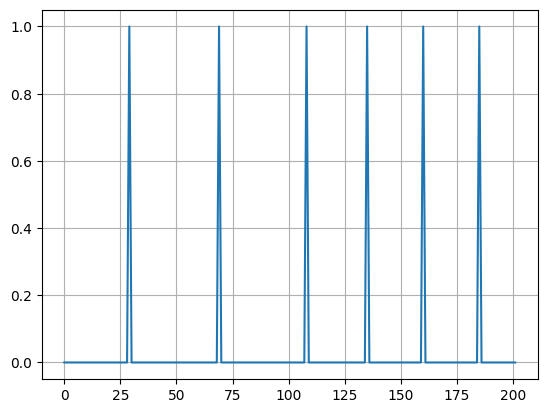

In [55]:
plt.plot(stats["rewards"])
plt.grid()
plt.show()

Your task it to evaluate the following quantities from the logs:
1. Discounted returns: $G[t] = \sum_{t'=t}^T \gamma ^ {t' - t}r[t]$, where $T$ is the total time of an episode.
2. State Values estimated by the agent: $V_{agent}[t] = \max_{a}Q_{agent}(s[t], a)$.
3. Q-spread: $\Delta Q[t] = \max_{a}Q_{agent}(s[t], a) - \min_{a}Q_{agent}(s[t], a)$

Create a new env: `env = make_final_env()`, play for 5 episodes (a full game has 5 lives, so it will be 1 full game).  
Plot rewards and the evaluated quantites for each of them.  
Using the plots, can you find points where the ball hits the wall?  
Where the ball hits the platform?  
Probably, you won't need all the quantities for that, but it's still good to check the behavior of a model.

The `merge_frame_stack_to_plot` function may be useful.

In [56]:
def get_discounted_returns(rewards: Reversible[float], gamma: float) -> list[float]:
    """
    Calculates G[t] for each t, given rewards and gamma.

    Tip: Iterate backwards through rewards and use the following relationship:
    G[t] = r[t] + gamma * G[t + 1]
    """
    returns_reverse: list[float] = []
    last_return: float = 0
    for r in reversed(rewards):
        # your code
        G = r + gamma * G
    returns = list(reversed(returns_reverse))
    return returns


## Bonus I (2 pts). Get High Score!

Get mean reward per life:
1. $\geq 20$: +1 pt
2. $\geq 40$: +2 pts

## Bonus II (2+ pts). Apply modifications to DQN.

* [Prioritized experience replay](https://arxiv.org/abs/1511.05952) (2 pts, please check for effective open-source implementations)
* [Noisy Nets](https://arxiv.org/abs/1706.10295) (2 pts, please, pay attention to the exploration policy and whether epsilon-greedy policy is used)
* [distributional RL](https://arxiv.org/abs/1707.06887)(distributional and distributed stand for different things here) (3 pts)
* Other modifications (2+ pts depending on complexity)

## Bonus III (2 pts). Distributed RL.

https://gymnasium.farama.org/api/vector/#gymnasium.vector.AsyncVectorEnv